In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install tensorflow # Install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

2026-04-01 21:41:42.046136: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775079702.221051      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775079702.276429      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775079702.719186      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775079702.719228      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775079702.719231      55 computation_placer.cc:177] computation placer alr

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shufanshahi/eye-disease-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/shufanshahi/eye-disease-image-dataset


In [3]:
import os
import pandas as pd

# Function to collect filepaths and labels
def get_filepaths_and_labels(root_dir):
    filepaths = []
    labels = []
    # Assuming the dataset structure is root_dir/Eye_Disease/CLASS_NAME/image.jpg
    dataset_base_dir = os.path.join(root_dir, 'Eye_Disease')
# Check if 'Eye_Disease' subdirectory exists, otherwise use root_dir directly
    if not os.path.isdir(dataset_base_dir):
        dataset_base_dir = root_dir

    for dirpath, dirnames, filenames in os.walk(dataset_base_dir):
        for filename in filenames:
            # Filter for common image file extensions
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                filepath = os.path.join(dirpath, filename)
                # The label is typically the name of the immediate parent directory
                label = os.path.basename(os.path.dirname(filepath))
                filepaths.append(filepath)
                labels.append(label)
    return filepaths, labels
    # 'path' variable is already defined from a previous cell
all_filepaths, all_labels = get_filepaths_and_labels(path)

# Create the DataFrame
df = pd.DataFrame({
    'filepaths': all_filepaths,
    'labels': all_labels
})

# Display the head of the DataFrame to verify it's created correctly
df.head()

,filepaths,labels
0,/kaggle/input/datasets/shufanshahi/eye-disease...,Macular Scar
1,/kaggle/input/datasets/shufanshahi/eye-disease...,Macular Scar
2,/kaggle/input/datasets/shufanshahi/eye-disease...,Macular Scar
3,/kaggle/input/datasets/shufanshahi/eye-disease...,Macular Scar
4,/kaggle/input/datasets/shufanshahi/eye-disease...,Macular Scar


Classes: ['Central Serous Chorioretinopathy', 'Diabetic Retinopathy', 'Disc Edema', 'Glaucoma', 'Healthy', 'Macular Scar', 'Myopia', 'Pterygium', 'Retinal Detachment', 'Retinitis Pigmentosa']
{'Diabetic Retinopathy': 4953, 'Glaucoma': 4229, 'Healthy': 3700, 'Myopia': 2751, 'Macular Scar': 2381, 'Retinitis Pigmentosa': 973, 'Disc Edema': 889, 'Retinal Detachment': 875, 'Central Serous Chorioretinopathy': 707, 'Pterygium': 119}


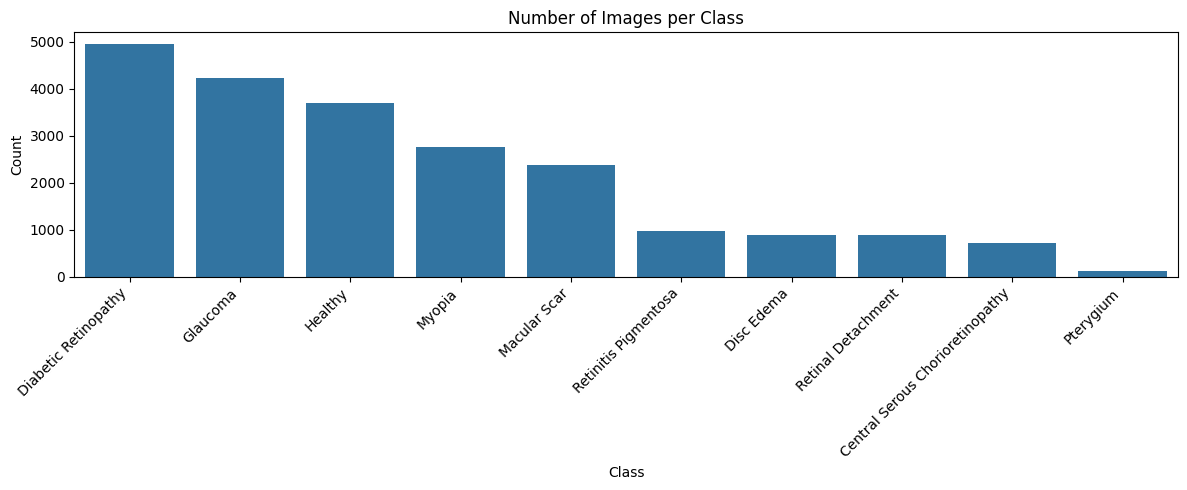

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os

# The dataframe 'df' already contains the filepaths and labels, which is more reliable.
# Use df to get class names and counts.

# Get class names from the 'labels' column of the DataFrame
class_names = sorted(df['labels'].unique().tolist())
print("Classes:", class_names)

# Count images per class using value_counts from the DataFrame
image_counts = df['labels'].value_counts().to_dict()

print(image_counts)

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(
    x=list(image_counts.keys()),
    y=list(image_counts.values())
)
plt.xticks(rotation=45, ha='right')
plt.title('Number of Images per Class')
plt.ylabel('Count')
plt.xlabel('Class')
plt.tight_layout()
plt.show()

In [5]:
# حذف Glaucoma من الـ DataFrame
df = df[df["labels"] != "Glaucoma"].reset_index(drop=True)

# تأكيد
print(df["labels"].value_counts())



labels
Diabetic Retinopathy                4953
Healthy                             3700
Myopia                              2751
Macular Scar                        2381
Retinitis Pigmentosa                 973
Disc Edema                           889
Retinal Detachment                   875
Central Serous Chorioretinopathy     707
Pterygium                            119
Name: count, dtype: int64


In [6]:
# حذف Macular Scar من الـ DataFrame
df = df[df["labels"] != "Macular Scar"].reset_index(drop=True)

# تأكيد
print(df["labels"].value_counts())



labels
Diabetic Retinopathy                4953
Healthy                             3700
Myopia                              2751
Retinitis Pigmentosa                 973
Disc Edema                           889
Retinal Detachment                   875
Central Serous Chorioretinopathy     707
Pterygium                            119
Name: count, dtype: int64


In [7]:
# حذف Macular Scar من الـ DataFrame
df = df[df["labels"] != "Central Serous Chorioretinopathy"].reset_index(drop=True)

# تأكيد
print(df["labels"].value_counts())



labels
Diabetic Retinopathy    4953
Healthy                 3700
Myopia                  2751
Retinitis Pigmentosa     973
Disc Edema               889
Retinal Detachment       875
Pterygium                119
Name: count, dtype: int64


In [8]:
DATASET_DIR = "/kaggle/input/eye-disease-image-dataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

In [9]:
print(len(df))
df.head()


14260


,filepaths,labels
0,/kaggle/input/datasets/shufanshahi/eye-disease...,Pterygium
1,/kaggle/input/datasets/shufanshahi/eye-disease...,Pterygium
2,/kaggle/input/datasets/shufanshahi/eye-disease...,Pterygium
3,/kaggle/input/datasets/shufanshahi/eye-disease...,Pterygium
4,/kaggle/input/datasets/shufanshahi/eye-disease...,Pterygium


In [10]:
classes = df['labels'].unique().tolist()
print("Classes:", classes)

print("\nImage counts per class:")
for cls in classes:
    count = (df['labels'] == cls).sum()
    print(f"{cls}: {count}")

Classes: ['Pterygium', 'Disc Edema', 'Healthy', 'Retinal Detachment', 'Retinitis Pigmentosa', 'Myopia', 'Diabetic Retinopathy']

Image counts per class:
Pterygium: 119
Disc Edema: 889
Healthy: 3700
Retinal Detachment: 875
Retinitis Pigmentosa: 973
Myopia: 2751
Diabetic Retinopathy: 4953


In [107]:
IMG_SIZE = (300,300)
BATCH_SIZE = 32
NUM_CLASSES = len(classes)

In [108]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [109]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["labels"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,   # 0.25 × 0.8 = 0.2
    random_state=42,
    stratify=train_val_df["labels"]
)

In [110]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)
validation_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 8556 validated image filenames belonging to 7 classes.
Found 2852 validated image filenames belonging to 7 classes.
Found 2852 validated image filenames belonging to 7 classes.


In [111]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 8556
Validation: 2852
Test: 2852


Classes (after removals): ['Diabetic Retinopathy', 'Disc Edema', 'Healthy', 'Myopia', 'Pterygium', 'Retinal Detachment', 'Retinitis Pigmentosa']
Image counts per class (after removals):
Diabetic Retinopathy: 4953
Healthy: 3700
Myopia: 2751
Retinitis Pigmentosa: 973
Disc Edema: 889
Retinal Detachment: 875
Pterygium: 119
                  Class  Original_Count
0  Diabetic Retinopathy            4953
1               Healthy            3700
2                Myopia            2751
3  Retinitis Pigmentosa             973
4            Disc Edema             889
5    Retinal Detachment             875
6             Pterygium             119


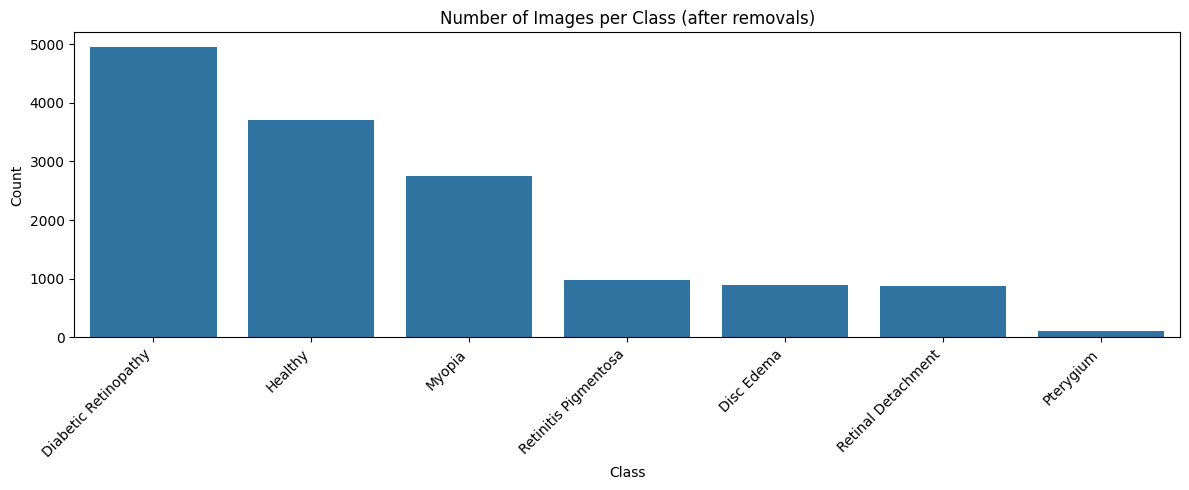

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the current state of df to get class names and counts
class_names = sorted(df['labels'].unique().tolist())
print("Classes (after removals):", class_names)

# Count images per class using value_counts from the DataFrame
image_counts = df['labels'].value_counts().to_dict()

print("Image counts per class (after removals):")
for cls, count in image_counts.items():
    print(f"{cls}: {count}")

df_counts = pd.DataFrame({
    "Class": image_counts.keys(),
    "Original_Count": image_counts.values()
})

print(df_counts)

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(
    x=list(image_counts.keys()),
    y=list(image_counts.values())
)
plt.xticks(rotation=45, ha='right')
plt.title('Number of Images per Class (after removals)')
plt.ylabel('Count')
plt.xlabel('Class')
plt.tight_layout()
plt.show()

In [113]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_df["labels"]

class_weights_vals = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights_named = dict(zip(np.unique(labels), class_weights_vals))
print(class_weights_named)


{'Diabetic Retinopathy': np.float64(0.4112670640261488), 'Disc Edema': np.float64(2.2932189761458055), 'Healthy': np.float64(0.5505791505791506), 'Myopia': np.float64(0.7403305356061262), 'Pterygium': np.float64(17.215291750503017), 'Retinal Detachment': np.float64(2.3281632653061224), 'Retinitis Pigmentosa': np.float64(2.092954990215264)}


In [114]:
df_counts = train_df["labels"].value_counts().to_frame(name="Original_Count")

df_counts["Class_Weight"] = df_counts.index.map(class_weights_named)

df_counts["Balanced_Effective_Count"] = (
    df_counts["Original_Count"] * df_counts["Class_Weight"]
)

print(df_counts)


                      Original_Count  Class_Weight  Balanced_Effective_Count
labels                                                                      
Diabetic Retinopathy            2972      0.411267               1222.285714
Healthy                         2220      0.550579               1222.285714
Myopia                          1651      0.740331               1222.285714
Retinitis Pigmentosa             584      2.092955               1222.285714
Disc Edema                       533      2.293219               1222.285714
Retinal Detachment               525      2.328163               1222.285714
Pterygium                         71     17.215292               1222.285714


In [115]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_generator.classes  # indices: 0,1,2,...

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(zip(np.unique(labels), class_weights))

print("class_weights:", class_weights)


class_weights: {np.int64(0): np.float64(0.4112670640261488), np.int64(1): np.float64(2.2932189761458055), np.int64(2): np.float64(0.5505791505791506), np.int64(3): np.float64(0.7403305356061262), np.int64(4): np.float64(17.215291750503017), np.int64(5): np.float64(2.3281632653061224), np.int64(6): np.float64(2.092954990215264)}


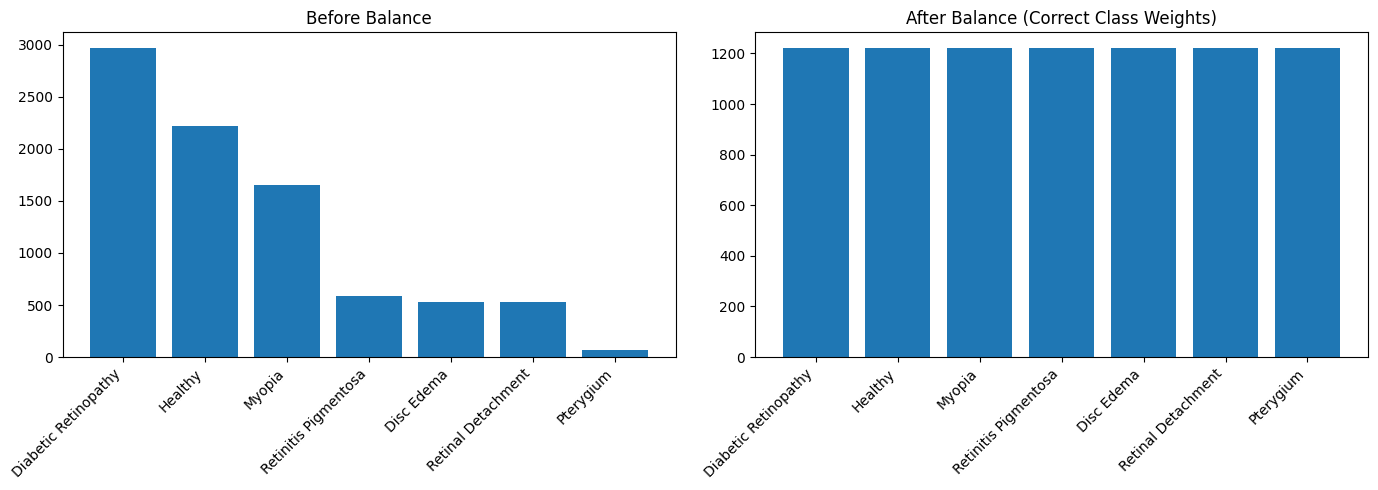

In [116]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.bar(df_counts.index, df_counts["Original_Count"])
plt.title("Before Balance")
plt.xticks(rotation=45, ha="right")

plt.subplot(1,2,2)
plt.bar(df_counts.index, df_counts["Balanced_Effective_Count"])
plt.title("After Balance (Correct Class Weights)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


In [117]:
base_model = keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(300,300, 3)
)
base_model.trainable = False

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [118]:
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)
from tensorflow import keras

# عدد الكلاسات (دايمًا خده من generator)
NUM_CLASSES = len(train_generator.class_indices)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(
    256,
    activation='relu',
    kernel_initializer='he_normal',
    kernel_regularizer=keras.regularizers.l2(1e-4)
)(x)

x = Dropout(0.5)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs=base_model.input, outputs=output)

# Explicitly build the model to ensure all variables are created
model.build(input_shape=(None, IMG_SIZE[0], IMG_SIZE[1], 3))

In [119]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-5,
        verbose=1
    ),

    ModelCheckpoint(
    "best_efficientnetb3.keras",   # 🔥 بدل .h5
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)
]


In [120]:
import tensorflow as tf

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),   # 👈 مهم
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [121]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,  # أو val_generator
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


2026-04-01 23:57:37.173797: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 23:57:37.331476: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 23:57:37.799637: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 23:57:37.946916: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 23:57:38.752016: E external/local_xla/xla/stream_

217/268 ━━━━━━━━━━━━━━━━━━━━ 46s 910ms/step - accuracy: 0.6203 - auc: 0.8892 - loss: 1.1748 - recall: 0.5840

2026-04-02 00:01:21.283922: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 00:01:21.426755: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 00:01:21.791445: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 00:01:21.938592: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 00:01:22.086190: E external/local_xla/xla/stream_

268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6382 - auc: 0.8984 - loss: 1.1098 - recall: 0.6048

2026-04-02 00:03:17.787741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 00:03:17.924822: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 00:03:18.245210: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 00:03:18.392501: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 00:03:19.179631: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from inf to 0.43479, saving model to best_efficientnetb3.keras
268/268 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.6386 - auc: 0.8985 - loss: 1.1087 - recall: 0.6052 - val_accuracy: 0.8583 - val_auc: 0.9873 - val_loss: 0.4348 - val_recall: 0.8292 - learning_rate: 0.0010
Epoch 2/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - accuracy: 0.8014 - auc: 0.9649 - loss: 0.5549 - recall: 0.7859
Epoch 2: val_loss improved from 0.43479 to 0.37116, saving model to best_efficientnetb3.keras
268/268 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.8014 - auc: 0.9649 - loss: 0.5548 - recall: 0.7859 - val_accuracy: 0.8927 - val_auc: 0.9882 - val_loss: 0.3712 - val_recall: 0.8846 - learning_rate: 0.0010
Epoch 3/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 945ms/step - accuracy: 0.8185 - auc: 0.9687 - loss: 0.5799 - recall: 0.8062
Epoch 3: val_loss improved from 0.37116 to 0.32538, saving model to best_efficientnetb3.keras
268/268 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - accuracy: 0.818

In [122]:
import numpy as np
from sklearn.metrics import classification_report

# Predict
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print("Classification Report:\n")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_labels,
    digits=2
))


90/90 ━━━━━━━━━━━━━━━━━━━━ 66s 613ms/step
Classification Report:

                      precision    recall  f1-score   support

Diabetic Retinopathy       0.99      0.93      0.96       991
          Disc Edema       0.90      0.97      0.93       178
             Healthy       0.92      0.96      0.94       740
              Myopia       0.93      0.90      0.92       550
           Pterygium       1.00      1.00      1.00        24
  Retinal Detachment       0.96      0.99      0.97       175
Retinitis Pigmentosa       0.93      0.98      0.95       194

            accuracy                           0.95      2852
           macro avg       0.95      0.96      0.95      2852
        weighted avg       0.95      0.95      0.95      2852



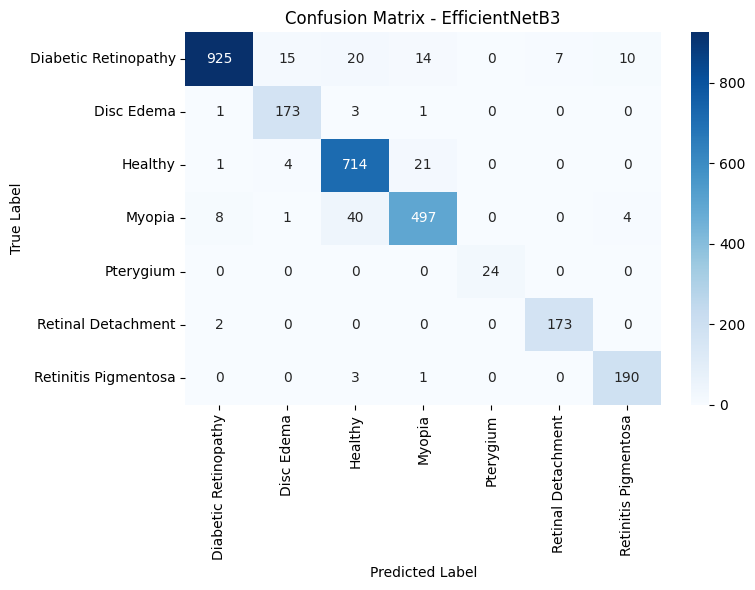

In [123]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix - EfficientNetB3")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()



plt.show()


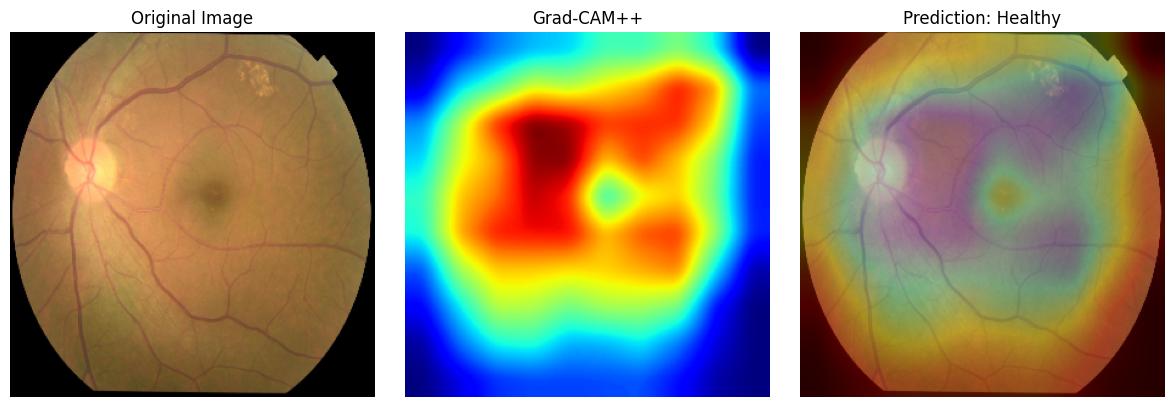

Prediction: Healthy


In [124]:
# =====================================
# 🔥 GRAD-CAM++ (ADVANCED VERSION)
# =====================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

LAST_CONV_LAYER = "top_conv"


# =====================================
# 🔹 Grad-CAM++ Heatmap
# =====================================
def make_gradcam_plus_plus(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)[0]
    conv_outputs = conv_outputs[0]

    # 🔥 Grad-CAM++ weights
    grads_squared = tf.square(grads)
    grads_cubed = grads_squared * grads

    denominator = 2 * grads_squared + tf.reduce_sum(
        conv_outputs * grads_cubed, axis=(0, 1), keepdims=True
    )

    denominator = tf.where(denominator != 0, denominator, tf.ones_like(denominator))

    alphas = grads_squared / denominator

    weights = tf.reduce_sum(alphas * tf.nn.relu(grads), axis=(0, 1))

    # Heatmap
    heatmap = tf.reduce_sum(conv_outputs * weights, axis=-1)

    # Normalize
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy(), int(pred_index)


# =====================================
# 🔹 Visualization (Smooth + Pro)
# =====================================
def show_gradcam_plus_plus(img_path):

    # Load image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    # Heatmap
    heatmap, pred_idx = make_gradcam_plus_plus(
        img_array, model, LAST_CONV_LAYER
    )

    class_names = list(train_generator.class_indices.keys())
    pred_label = class_names[pred_idx]

    # Original image
    original = cv2.imread(img_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    original = cv2.resize(original, IMG_SIZE)

    # Resize
    heatmap = cv2.resize(heatmap, (IMG_SIZE[1], IMG_SIZE[0]))

    # Normalize
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    # Convert to 0-255
    heatmap = np.uint8(255 * heatmap)

    # 🔥 Smooth قوي جدًا
    heatmap = cv2.GaussianBlur(heatmap, (31, 31), 0)

    # Color
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay (احترافي)
    overlay = cv2.addWeighted(original, 0.7, heatmap_color, 0.3, 0)

    # =====================================
    # 🔹 Plot
    # =====================================
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM++")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title(f"Prediction: {pred_label}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Prediction:", pred_label)


# =====================================
# 🔹 Run
# =====================================
img_path = "/kaggle/input/datasets/shufanshahi/eye-disease-image-dataset/Eye Disease Image Dataset/Original Dataset/Healthy/Healthy1011.jpg"

show_gradcam_plus_plus(img_path)

In [125]:
!pip install transformers accelerate bitsandbytes -q

In [126]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# تحميل موديل EfficientNet
vision_model = load_model('best_efficientnetb3.h5')

class_names = [
    'Diabetic Retinopathy',
    'Disc Edema',
    'Healthy',
    'Myopia',
    'Pterygium',
    'Retinal Detachment',
    'Retinitis Pigmentosa'
]

print("Vision model loaded successfully!")

Vision model loaded successfully!


In [127]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "microsoft/Phi-3-mini-4k-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

llm_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Phi-3 loaded successfully!")

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Phi-3 loaded successfully!


In [128]:
def predict_disease(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    preds = vision_model.predict(img_array)
    class_idx = np.argmax(preds[0])
    confidence = float(np.max(preds[0]))
    disease = class_names[class_idx]

    return disease, confidence

In [129]:
def local_llm_explain(disease, confidence):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    prompt = f"""
You are an ophthalmology AI.

Write exactly 5 short medical lines about this prediction:

Prediction: {disease}
Confidence: {confidence:.2f}

Structure:
1. Prediction statement.
2. Short definition.
3. Key symptoms.
4. Severity level.
5. What to do next.

Only write the 5 lines. No titles. No repetition.
"""

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=120,
        temperature=0.1,
        do_sample=False,   
        repetition_penalty=1.2
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # حذف البرومبت من البداية
    cleaned = text.replace(prompt, "").strip()

    lines = cleaned.split("\n")
    final_output = "\n".join(lines[:5])

    return final_output.strip()

In [130]:
original, heatmap, overlay = generate_gradcam_plus_plus(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Predicted disease: Retinal Detachment
Confidence: 1.00

AI Medical Report:

**Solution **Retinal detachment is a serious condition wherein the retina peels away from its underlying layer of support tissue at the back of the eye, leading potentially to vision loss if not treated promptly and effectively; key signs include sudden flashes of light (floaters), shadow or curtain effect over part of one's visual field indicating progressive peripheral sight impairment—considered severe due to risk for permanent blindness in affected individuals who should seek immediate emergency care with specialist consultation as surgery may be required urgently.*

Grad-CAM:



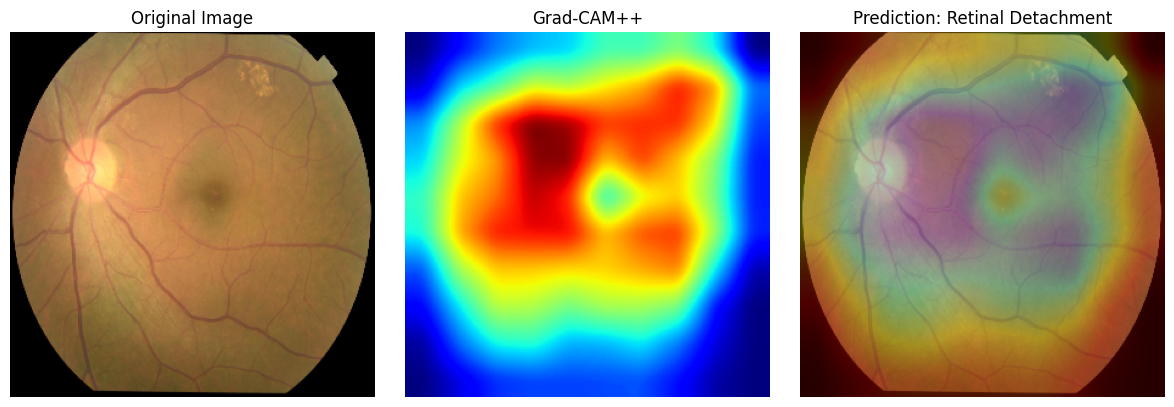

In [131]:
disease, conf = predict_disease("/kaggle/input/datasets/shufanshahi/eye-disease-image-dataset/Eye Disease Image Dataset/Original Dataset/Retinal Detachment/Retinal Detachment100.jpg")

print(f"Predicted disease: {disease}")
print(f"Confidence: {conf:.2f}")

print("\nAI Medical Report:\n")

report = local_llm_explain(disease, conf)
print(report)
print("\nGrad-CAM:\n")

plt.figure(figsize=(12,4))

# 🔹 Original
plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

# 🔹 Heatmap
plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM++")
plt.axis("off")

# 🔹 Overlay
plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title(f"Prediction: {disease}")
plt.axis("off")

plt.tight_layout()
plt.show()